# 01 — Dataset Inspection

**Milestone 1 · Task 1:** load the raw Kickstarter scrape, review the columns,
count the rows, and understand what campaign information is available.

This notebook makes no changes to the data. It only looks. Every cleaning
decision made in `02_cleaning.ipynb` traces back to something found here.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loading import load_raw, raw_overview

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 1.1 Loading — the encoding trap

The obvious call fails. The raw file is **not UTF-8**: it contains byte
`0x92` (a Windows-1252 smart quote) at position 14,997. And it is not
clean cp1252 either — byte `0x8f` at position 82,610 is undefined in that
codepage. `latin-1` maps every byte in `0x80`–`0xFF` to a character
without raising, so it is the only encoding that reads the whole file.

Nothing we model on is affected: the offending bytes are curly quotes and
dashes inside project titles.

In [2]:
# Demonstrate the failure so the decision is documented, not just asserted.
for enc in ["utf-8", "cp1252", "latin-1"]:
    try:
        pd.read_csv("../data/DSI_kickstarterscrape_dataset_csv.zip", encoding=enc, nrows=5000)
        print(f"{enc:10s} OK")
    except UnicodeDecodeError as e:
        print(f"{enc:10s} FAILED — {str(e)[:80]}")

utf-8      FAILED — 'utf-8' codec can't decode byte 0x92 in position 12: invalid start byte
cp1252     FAILED — 'charmap' codec can't decode byte 0x8f in position 82610: character maps to <und
latin-1    OK


In [3]:
raw = load_raw("../data/DSI_kickstarterscrape_dataset_csv.zip")
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print("\nThe challenge brief says ~45,957 observations and 17 columns — matches exactly.")

Shape: 45,957 rows x 17 columns

The challenge brief says ~45,957 observations and 17 columns — matches exactly.


## 1.2 Column inventory

Column names are normalised to snake_case at load time (`project id` →
`project_id`, and so on) so no downstream code needs bracket access.

In [4]:
overview = raw_overview(raw)
overview

,column,dtype,nulls,null_pct,n_unique,example
0,project_id,int64,0,0.00,45815,39409
1,name,str,0,0.00,45754,WHILE THE TREES SLEEP
2,url,str,0,0.00,45814,http://www.kickstarter.com/projects/emiliesabath
3,category,str,0,0.00,14,Film & Video
4,subcategory,str,0,0.00,51,Short Film
5,location,str,1322,2.88,4849,"Columbia, MO"
6,status,str,0,0.00,5,successful
7,goal,float64,0,0.00,1837,10500.0
8,pledged,float64,12,0.03,10950,11545.0
9,funded_percentage,float64,0,0.00,21976,1.09952381


### What each column actually means

| Column | Meaning | Known at launch? |
|---|---|---|
| `project_id`, `name`, `url` | Identifiers | — |
| `category`, `subcategory` | Kickstarter taxonomy | ✅ |
| `location` | Free-text `"City, ST"` | ✅ |
| `goal` | Funding target, USD | ✅ |
| `duration` | Campaign length in days (fractional) | ✅ |
| `levels` | Number of reward tiers | ✅ |
| `reward_levels` | The tier amounts as a string | ✅ |
| `status` | successful / failed / live / canceled / suspended | ❌ target |
| `pledged` | Dollars raised | ❌ outcome |
| `funded_percentage` | pledged ÷ goal | ❌ outcome |
| `backers` | Number of people who pledged | ❌ outcome |
| `comments` | Comment count | ❌ outcome |
| `updates` | Creator posts during the campaign | ⚠️ **during** |
| `funded_date` | Campaign **end** date | ❌ |

The `updates` row is the one to notice. It is neither a clean launch-time
feature nor a pure outcome, and it turns out to matter enormously — see
notebook 04.

## 1.3 The target variable

In [5]:
status_counts = raw["status"].value_counts()
status_pct = raw["status"].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"count": status_counts, "pct": status_pct}).to_string())

resolved = raw["status"].isin(["successful", "failed"]).sum()
print(f"\nResolved (successful or failed): {resolved:,}")
print(f"Unusable for binary classification: {len(raw) - resolved:,}")

            count    pct
status                  
successful  22969  49.98
failed      18996  41.33
live         3929   8.55
canceled       59   0.13
suspended       4   0.01

Resolved (successful or failed): 41,965
Unusable for binary classification: 3,992


`live` campaigns (3,929) have no outcome yet. `canceled` (59) and
`suspended` (4) ended for reasons unrelated to whether they would have
funded — a creator pulling out, or a terms violation. All three go.

Among resolved campaigns the split is roughly 55/45 successful, which is
only mildly imbalanced. That matters for interpreting results: a model
that always guesses "successful" already scores **54.8% accuracy**, so the
80% target represents real lift, not a class-balance artefact.

## 1.4 Missing values

In [6]:
nulls = raw.isna().sum()
print(nulls[nulls > 0].to_string())
print(f"\nRows with at least one null: {raw.isna().any(axis=1).sum():,}")

location         1322
pledged            12
reward_levels      59

Rows with at least one null: 1,377


Only three columns have nulls, and they are not equally important:

- **`location` (1,322)** — will mostly be removed by the US filter anyway.
- **`reward_levels` (59)** — needed for tier features, so these rows go.
- **`pledged` (12)** — a leaky outcome column we will never model on.
  Dropping rows for this column's sake would delete usable campaigns.

This is why notebook 02 runs `dropna` on *modelling columns only* rather
than on all columns, which is what the original project did.

## 1.5 Duplicates

In [7]:
print(f"Fully identical rows:        {raw.duplicated().sum():,}")
print(f"Duplicated project_id:       {raw['project_id'].duplicated().sum():,}")
print(f"Duplicated name + url:       {raw.duplicated(subset=['name', 'url']).sum():,}")

dupe_ids = raw.loc[raw["project_id"].duplicated(keep=False), "project_id"].unique()
example = raw[raw["project_id"] == dupe_ids[0]]
print(f"\nExample duplicate pair (project_id={dupe_ids[0]}):")
example[["project_id", "name", "status", "goal", "pledged", "backers", "updates"]]

Fully identical rows:        89
Duplicated project_id:       142
Duplicated name + url:       142

Example duplicate pair (project_id=2140333236):


,project_id,name,status,goal,pledged,backers,updates
45651,2140333236,Imagined Family Heirlooms: An Archive of Inher...,successful,5800.0,8521.0,110,5
45652,2140333236,Imagined Family Heirlooms: An Archive of Inher...,successful,5800.0,8521.0,110,5


`project_id` is Kickstarter's own primary key, so a repeated value is a
genuine duplicate scrape rather than two different campaigns. Some
duplicate pairs differ slightly in `pledged`/`backers`/`updates`, which
means the scraper captured the same campaign twice at different moments.
Keeping the first occurrence is the right call.

## 1.6 Location structure

The brief says to split location into City and State. Before writing a
`split(",")`, check how well-formed the field actually is.

In [8]:
loc = raw["location"].dropna()
comma_counts = loc.str.count(",").value_counts().sort_index()
print("Commas per location value:")
print(comma_counts.to_string())

print("\nEvery value that is not exactly 'City, ST':")
for v in loc[loc.str.count(",") != 1].unique():
    print(f"  {v!r}")

Commas per location value:
location
0        1
1    44627
2        7

Every value that is not exactly 'City, ST':


  'St Croix, Virgin Islands, U.S.'
  'Maar'
  'Nakagyo Ward, Kyoto, Japan'
  'Edinburgh, Scotland, United Kingdom'
  'Cruz Bay, Virgin Islands, U.S.'
  'Kamigyo Ward, Kyoto, Japan'
  '10, Middleburg, MD'


Eight rows break the pattern, in three different ways:

- `"St Croix, Virgin Islands, U.S."` — a US **territory**, spelled out
- `"Nakagyo Ward, Kyoto, Japan"` — international, two commas
- `"10, Middleburg, MD"` — malformed, with a stray leading number
- `"Maar"` — no comma at all

Splitting on the **last** comma (`rsplit`) handles the malformed case
correctly and leaves the international ones with a long state token that
the US filter will reject anyway.

In [9]:
tokens = loc.str.rsplit(",", n=1).str[-1].str.strip()
two_char = sorted(tokens[tokens.str.len() == 2].unique())
print(f"Distinct 2-character tokens: {len(two_char)}")
print(two_char)

from src.cleaning import US_STATES
odd = [t for t in two_char if t not in US_STATES]
print(f"\n2-char tokens not matching the whitelist EXACTLY: {odd}")
print(f"Same check, case-insensitively: "
      f"{[t for t in two_char if t.upper() not in US_STATES]}")

Distinct 2-character tokens: 52
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'Mt', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

2-char tokens not matching the whitelist EXACTLY: ['Mt']
Same check, case-insensitively: []


### A case-sensitivity trap

`'Mt'` looks like junk against an upper-case whitelist. It is not — it is
**Montana**, mis-capitalised. Check the cities to be sure:

In [10]:
mt_rows = raw[raw["location"].astype("string").str.strip().str.endswith(", Mt", na=False)]
print(f"Rows with state token 'Mt': {len(mt_rows)}")
print(f"Rows with state token 'MT': "
      f"{int(tokens.eq('MT').sum())}")
print()
print("Cities:", sorted(mt_rows['location'].str.rsplit(',', n=1).str[0].str.strip().unique())[:12])

Rows with state token 'Mt': 36
Rows with state token 'MT': 89

Cities: ['Belgrade', 'Big Sandy', 'Big Timber', 'Boulder', 'Browning', 'Clyde Park', 'Columbia Falls', 'Crow Agency', 'Gallatin Gateway', 'Gardiner', 'Glacier National Park', 'Kalispell']


Kalispell, Whitefish, Gallatin Gateway, Glacier National Park — Montana,
beyond doubt. One of the campaigns is even titled *"Saving Montana
History"*.

This is the **same bug as `Film &amp; Video`** in a different costume: one
real entity encoded two ways. Two ways to get it wrong:

- A case-*sensitive* whitelist silently deletes 36 real campaigns.
- A "token is 2 characters" rule keeps them, but as a **separate state
  level** from `MT`, so Montana one-hot encodes into two columns.

The fix is a case-insensitive whitelist match plus upper-casing the code,
so `Mt` and `MT` group as one state. Checked the same way, city names have
no case variants inside the US — the only one in the whole file is
`Dar Es Salaam` / `Dar es Salaam`, in Tanzania.

In [11]:
non_us = tokens[tokens.str.len() != 2].value_counts()
print(f"Non-US campaigns: {non_us.sum():,} across {non_us.nunique()} countries")
print(non_us.head(12).to_string())

Non-US campaigns: 2,331 across 43 countries
location
Canada            284
United Kingdom    216
Germany           119
Mexico             84
France             81
Italy              74
India              68
China              60
Australia          57
Japan              55
Israel             51
South Africa       47


## 1.7 Numeric columns — where the dirt is

In [12]:
raw[["goal", "duration", "levels", "updates", "pledged", "backers", "comments"]].describe().T

,count,mean,std,min,25%,50%,75%,max
goal,45957.0,11942.709522,188758.303062,0.01,1800.0,4000.0,9862.00,21474836.47
duration,45957.0,39.995547,17.414458,1.00,30.0,32.0,48.39,91.96
levels,45957.0,8.004939,4.233907,0.00,5.0,7.0,10.00,80.00
updates,45957.0,4.085080,6.439220,0.00,0.0,2.0,6.00,149.00
pledged,45945.0,4980.749679,56741.621944,0.00,196.0,1310.0,4165.00,10266845.00
backers,45957.0,69.973192,688.628479,0.00,5.0,23.0,59.00,87142.00
comments,45957.0,8.379529,174.015737,0.00,0.0,0.0,3.00,19311.00


### `goal`

In [13]:
print(f"Median goal:  ${raw['goal'].median():,.0f}")
print(f"Mean goal:    ${raw['goal'].mean():,.0f}   <- dragged up by outliers")
print(f"Max goal:     ${raw['goal'].max():,.2f}")
print(f"\n2**31 - 1 in cents = ${(2**31 - 1) / 100:,.2f}")
print("\nThe maximum goal is exactly the 32-bit signed integer limit — this is a")
print("scraper overflow artefact, not a real fundraising target.")
print(f"\nGoals under $10:      {(raw['goal'] < 10).sum()}")
print(f"Goals over $1M:       {(raw['goal'] > 1_000_000).sum()}")

raw.nlargest(6, "goal")[["name", "goal", "status", "duration"]]

Median goal:  $4,000
Mean goal:    $11,943   <- dragged up by outliers
Max goal:     $21,474,836.47

2**31 - 1 in cents = $21,474,836.47

The maximum goal is exactly the 32-bit signed integer limit — this is a
scraper overflow artefact, not a real fundraising target.

Goals under $10:      44
Goals over $1M:       10


,name,goal,status,duration
12178,Legend of The Stolen Guitar,21474836.47,failed,83.10
10306,Space Folk Album: Lunar Aid 1985,21474836.00,live,30.00
20735,TRONICA EVOLUTION. Blogger. Superhero. Mother.,20000000.00,failed,90.04
2958,Keturah and Lord Death--The Movie,15000000.00,live,50.94
26680,Cool Roofs! Let the phenomenon begin!,5250000.00,live,30.00
22244,Salvators' Winery &amp; Restaurant,3500000.00,failed,60.00


### `duration`

count    45957.000000
mean        39.995547
std         17.414458
min          1.000000
25%         30.000000
50%         32.000000
75%         48.390000
max         91.960000

Fractional durations (not whole days): 51.3% of rows
Durations over 60 days: 4,990

Kickstarter capped campaigns at 60 days in June 2011. Anything longer is a
pre-2011 campaign — a different platform regime, worth a flag not a drop.


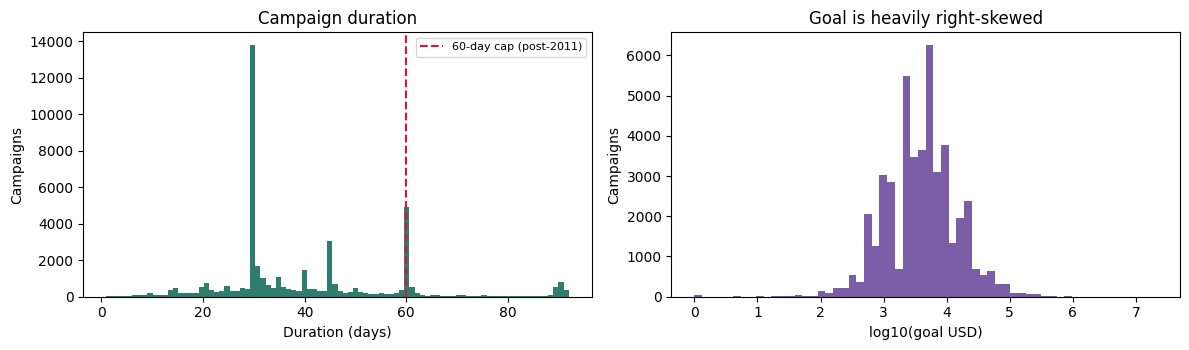

In [14]:
print(raw["duration"].describe().to_string())
print(f"\nFractional durations (not whole days): "
      f"{(raw['duration'] % 1 != 0).mean():.1%} of rows")
print(f"Durations over 60 days: {(raw['duration'] > 60).sum():,}")
print("\nKickstarter capped campaigns at 60 days in June 2011. Anything longer is a")
print("pre-2011 campaign — a different platform regime, worth a flag not a drop.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(raw["duration"], bins=90, color="#2E7D6F")
axes[0].axvline(60, color="crimson", ls="--", label="60-day cap (post-2011)")
axes[0].set_xlabel("Duration (days)"); axes[0].set_ylabel("Campaigns")
axes[0].set_title("Campaign duration"); axes[0].legend(fontsize=8)
axes[1].hist(np.log10(raw["goal"].clip(lower=1)), bins=60, color="#7B5EA7")
axes[1].set_xlabel("log10(goal USD)"); axes[1].set_ylabel("Campaigns")
axes[1].set_title("Goal is heavily right-skewed")
plt.tight_layout(); plt.show()

## 1.8 The category label bug

This is the single most consequential thing in the raw file.

In [15]:
print(f"Apparent distinct categories:    {raw['category'].nunique()}")
print(f"Apparent distinct subcategories: {raw['subcategory'].nunique()}")
print()
raw["category"].value_counts().to_frame("count")

Apparent distinct categories:    14
Apparent distinct subcategories: 51



,count
category,
Film &amp; Video,13053
Music,10913
Publishing,4770
Art,3992
Theater,2492
Design,1768
Games,1738
Photography,1514
Food,1439


Look at the list carefully: **`Film &amp; Video` and `Film & Video` are both
there**, as separate categories. They are the same category — the scraper
never decoded HTML entities, so the platform's largest category is split in
two, with the smaller group masquerading as a rare category.

In [16]:
import html

affected = {}
for col in ["category", "subcategory"]:
    bad = raw[col][raw[col].str.contains(r"&[a-z]+;", regex=True, na=False)].unique()
    affected[col] = list(bad)
    print(f"{col}: {list(bad)}")

print()
for col in ["category", "subcategory"]:
    before = raw[col].nunique()
    after = raw[col].map(html.unescape).nunique()
    print(f"{col:12s} {before} distinct -> {after} after html.unescape()")

category: ['Film &amp; Video']
subcategory: ['Film &amp; Video', 'Board &amp; Card Games', 'Country &amp; Folk']

category     14 distinct -> 13 after html.unescape()
subcategory  51 distinct -> 49 after html.unescape()


Three subcategories are affected too (`Board &amp; Card Games`,
`Country &amp; Folk`, `Film &amp; Video`). Left unfixed, this splits the
largest category on the platform into a big group and a small one, and any
one-hot encoder will treat the small one as a rare separate category.

## 1.9 `funded_date` is the END date

The name is misleading. Compare it against `duration` to confirm.

In [17]:
sample = raw.head(3)[["name", "funded_date", "duration"]]
end = pd.to_datetime(raw["funded_date"], format="%a, %d %b %Y %H:%M:%S %z", utc=True)
launch = end - pd.to_timedelta(raw["duration"], unit="D")
print(f"Date range of funded_date: {end.min().date()} to {end.max().date()}")
print(f"Implied launch dates:      {launch.min().date()} to {launch.max().date()}")
print(f"Unparseable dates: {end.isna().sum()}")
print()
pd.DataFrame({
    "name": sample["name"].str[:30],
    "end (funded_date)": end.head(3).dt.date,
    "duration": sample["duration"],
    "implied launch": launch.head(3).dt.date,
})

Date range of funded_date: 2009-05-03 to 2012-08-01
Implied launch dates:      2009-04-21 to 2012-06-03
Unparseable dates: 0



,name,end (funded_date),duration,implied launch
0,WHILE THE TREES SLEEP,2011-08-19,30.00,2011-07-20
1,Educational Online Trading Car,2010-08-02,47.18,2010-06-15
2,STRUM,2012-06-08,28.00,2012-05-11


So `launch_date = funded_date − duration`. This is worth recovering for two
reasons: it yields launch-timing features that are legitimately known at
prediction time, and it enables a **chronological** train/test split, which
is a more honest evaluation than a random one for a forecasting problem.

## 1.10 Reward levels — a parsing trap

In [18]:
for v in raw["reward_levels"].dropna().head(3):
    print(repr(v))

'$25,$50,$100,$250,$500,$1,000,$2,500'
'$1,$5,$10,$25,$50'
'$1,$10,$25,$40,$50,$100,$250,$1,000,$1,337,$9,001'


In [19]:
example = "$25,$50,$100,$250,$500,$1,000,$2,500"
naive = example.split(",")
print(f"Naive .split(','):  {naive}")
print(f"\n-> 7 real tiers become {len(naive)} fragments, and '$1,000' becomes "
      f"'$1' and '000'.")
print("The amounts contain thousands separators, so the delimiter is ambiguous.")
print("Notebook 03 resolves this with a regex that only treats a comma as a")
print("thousands mark when exactly three digits follow it.")

Naive .split(','):  ['$25', '$50', '$100', '$250', '$500', '$1', '000', '$2', '500']

-> 7 real tiers become 9 fragments, and '$1,000' becomes '$1' and '000'.
The amounts contain thousands separators, so the delimiter is ambiguous.
Notebook 03 resolves this with a regex that only treats a comma as a
thousands mark when exactly three digits follow it.


## Findings — Task 1

| # | Finding | Consequence |
|---|---|---|
| 1 | File is neither UTF-8 nor cp1252 | Load with `encoding="latin-1"` |
| 2 | 45,957 × 17, matching the brief | Right dataset confirmed |
| 3 | 3,992 unresolved campaigns (live/canceled/suspended) | Drop → 41,965 |
| 4 | 55/45 class balance | Majority baseline = **54.8%** accuracy |
| 5 | `Film &amp; Video` ≠ `Film & Video` | Unescape HTML **before** grouping |
| 6 | 142 duplicated `project_id`s | Dedupe on the platform's own key |
| 7 | Max goal = 2³¹−1 cents | Scraper overflow; drop the row |
| 8 | 8 malformed `location` values; Montana appears as both `MT` and `Mt` | `rsplit` + **case-insensitive** state whitelist |
| 9 | `funded_date` is the **end** date | Recover `launch_date = end − duration` |
| 10 | `reward_levels` has commas inside amounts | Naive `split(",")` corrupts every $1,000+ tier |
| 11 | Nulls only in `location`, `reward_levels`, `pledged` | Don't `dropna` on all columns — `pledged` is leaky anyway |

**Next:** `02_cleaning.ipynb` turns each of these into an auditable
transformation with a logged row count.